In [26]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (1).csv


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

In [28]:
# Load the dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [29]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [30]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Dataset shape:", df.shape)

Number of rows: 7043
Number of columns: 21
Dataset shape: (7043, 21)


In [31]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [32]:
print("Data Types:")
print(df.dtypes)

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [33]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [34]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [35]:
print("TotalCharges data type:", df["TotalCharges"].dtype)

print("\nNumber of blank TotalCharges:")
print((df["TotalCharges"].str.strip() == "").sum())

TotalCharges data type: object

Number of blank TotalCharges:
11


In [63]:
duplicate_count= df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicate rows removed.")
else:
    print("No duplicate rows found.")

Number of duplicate rows: 0
No duplicate rows found.


In [62]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("Missing TotalCharges after conversion:")
print(df["TotalCharges"].isnull().sum())

df = df.dropna(subset=["TotalCharges"])

print("Dataset shape after removing missing values:", df.shape)

Missing TotalCharges after conversion:
11
Dataset shape after removing missing values: (7032, 22)


In [38]:
print("Churn values:")
print(df["Churn"].value_counts())

print("\nChurn percentages:")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn values:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentages:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


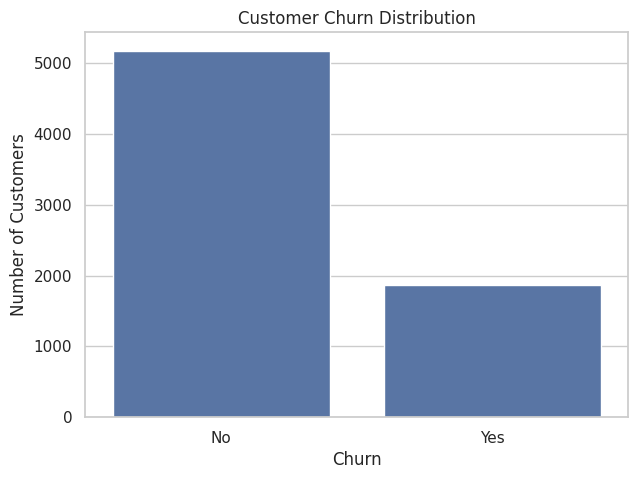

In [39]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Churn",
    order=["No", "Yes"]
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

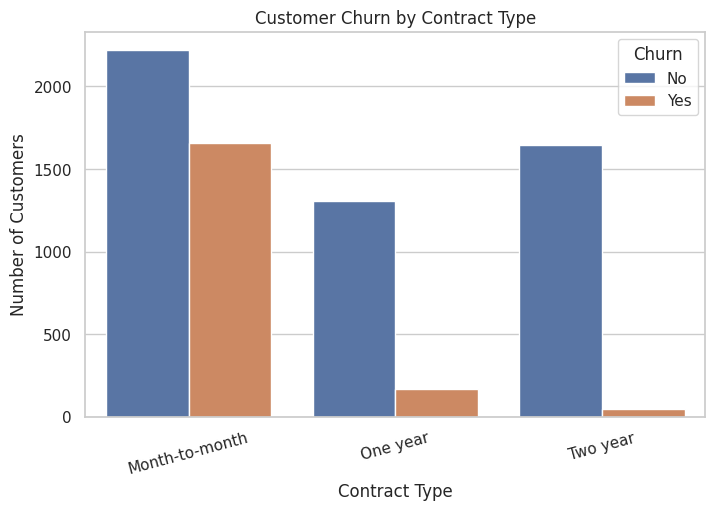

In [40]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)
plt.show()

Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn, dtype: float64


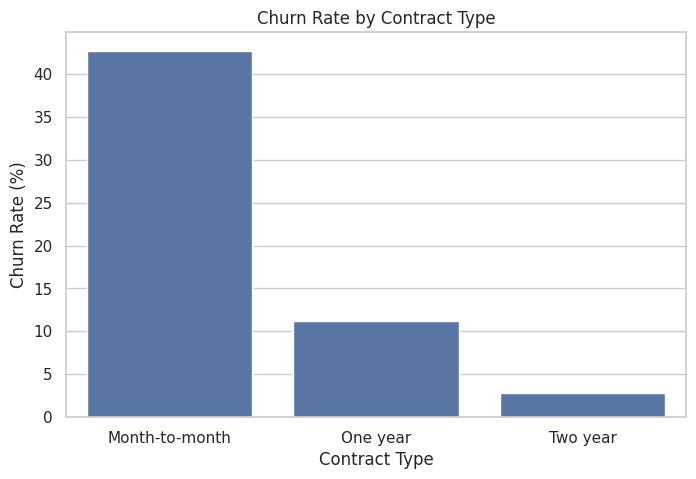

In [41]:
contract_churn = (
    df.groupby("Contract")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

print(contract_churn.round(2))

plt.figure(figsize=(8, 5))

sns.barplot(
    x=contract_churn.index,
    y=contract_churn.values
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.show()

TenureGroup
0-12 months     47.44
13-24 months    28.71
25-48 months    20.39
49-60 months    14.42
61+ months       6.61
Name: Churn, dtype: float64


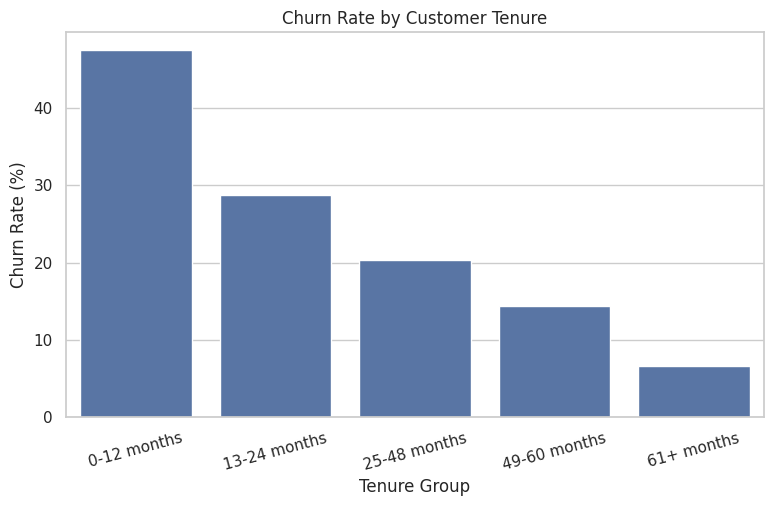

In [42]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 60, 100],
    labels=[
        "0-12 months",
        "13-24 months",
        "25-48 months",
        "49-60 months",
        "61+ months"
    ]
)
tenure_churn = (
    df.groupby("TenureGroup", observed=False)["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

print(tenure_churn.round(2))

plt.figure(figsize=(9, 5))

sns.barplot(
    x=tenure_churn.index,
    y=tenure_churn.values
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=15)
plt.show()

InternetService
DSL            18.96
Fiber optic    41.89
No              7.40
Name: Churn, dtype: float64


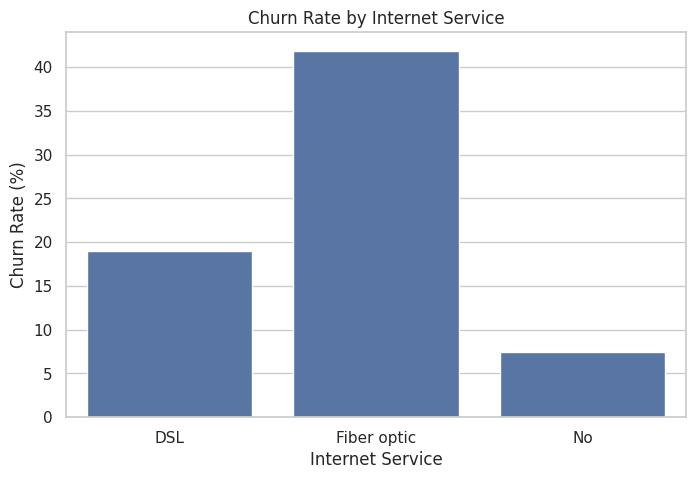

In [43]:
internet_churn = (
    df.groupby("InternetService")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

print(internet_churn.round(2))

plt.figure(figsize=(8, 5))

sns.barplot(
    x=internet_churn.index,
    y=internet_churn.values
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")

plt.show()

In [44]:
# Remove the EDA-only tenure group
model_df = df.drop(columns=["TenureGroup"])

# Convert Churn into binary values
model_df["Churn"] = (
    model_df["Churn"] == "Yes"
).astype(int)

# Separate features and target
X = model_df.drop(
    columns=["Churn", "customerID"]
)

y = model_df["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 19)
y shape: (7043,)


In [45]:
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 5634
Testing records: 1409


In [47]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numerical_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])

In [48]:
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000))
])

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [49]:
random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        )
    )
])

random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [50]:
logistic_predictions = logistic_model.predict(X_test)

random_forest_predictions = random_forest_model.predict(X_test)

print("Predictions generated successfully.")

Predictions generated successfully.


In [51]:
logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

logistic_precision = precision_score(
    y_test,
    logistic_predictions
)

logistic_recall = recall_score(
    y_test,
    logistic_predictions
)

logistic_f1 = f1_score(
    y_test,
    logistic_predictions
)

print("Logistic Regression")
print("-------------------")
print("Accuracy :", round(logistic_accuracy, 4))
print("Precision:", round(logistic_precision, 4))
print("Recall   :", round(logistic_recall, 4))
print("F1-Score :", round(logistic_f1, 4))

Logistic Regression
-------------------
Accuracy : 0.8055
Precision: 0.6572
Recall   : 0.5588
F1-Score : 0.604


In [52]:
rf_accuracy = accuracy_score(
    y_test,
    random_forest_predictions
)

rf_precision = precision_score(
    y_test,
    random_forest_predictions
)

rf_recall = recall_score(
    y_test,
    random_forest_predictions
)

rf_f1 = f1_score(
    y_test,
    random_forest_predictions
)

print("Random Forest")
print("-------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1-Score :", round(rf_f1, 4))

Random Forest
-------------
Accuracy : 0.7786
Precision: 0.6062
Recall   : 0.4733
F1-Score : 0.5315


In [53]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy": [
        logistic_accuracy,
        rf_accuracy
    ],

    "Precision": [
        logistic_precision,
        rf_precision
    ],

    "Recall": [
        logistic_recall,
        rf_recall
    ],

    "F1-Score": [
        logistic_f1,
        rf_f1
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046
1,Random Forest,0.778566,0.606164,0.473262,0.531532


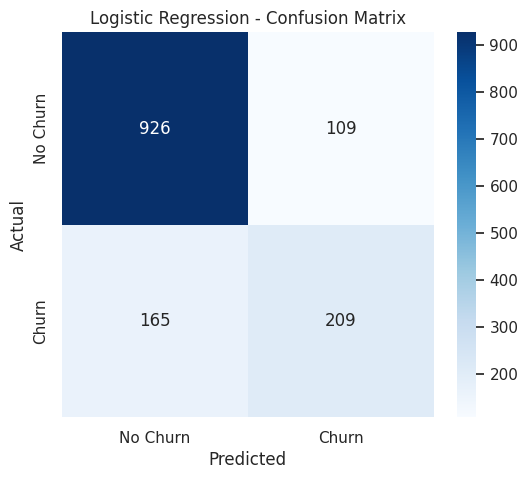

In [54]:
cm_logistic = confusion_matrix(
    y_test,
    logistic_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

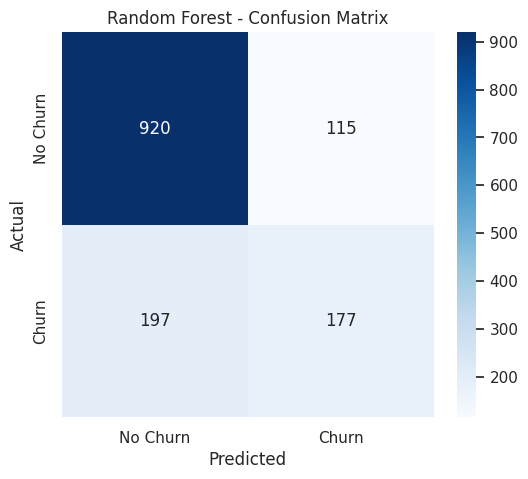

In [55]:
cm_rf = confusion_matrix(
    y_test,
    random_forest_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [56]:
print("Logistic Regression Classification Report")
print(
    classification_report(
        y_test,
        logistic_predictions,
        target_names=["No Churn", "Churn"]
    )
)
print("Random Forest Classification Report")
print(
    classification_report(
        y_test,
        random_forest_predictions,
        target_names=["No Churn", "Churn"]
    )
)

Logistic Regression Classification Report
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

Random Forest Classification Report
              precision    recall  f1-score   support

    No Churn       0.82      0.89      0.86      1035
       Churn       0.61      0.47      0.53       374

    accuracy                           0.78      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409



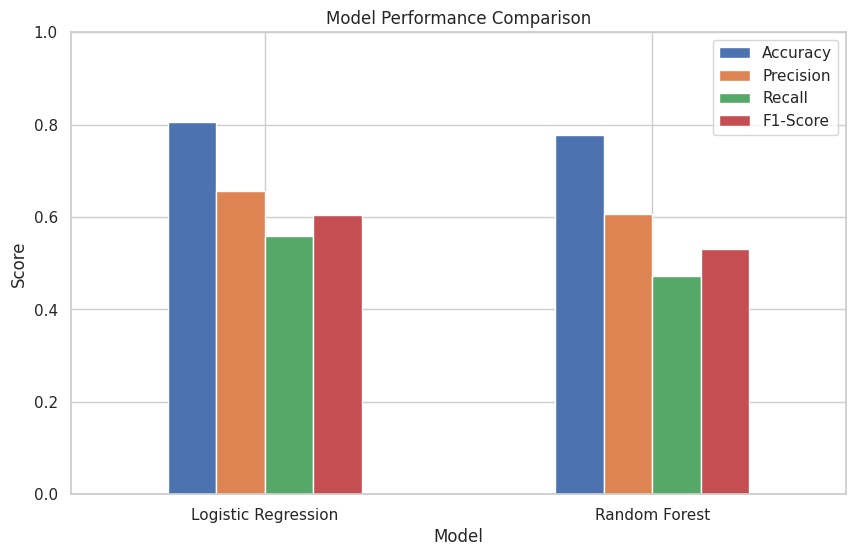

In [57]:
results.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.legend()
plt.show()

In [60]:
sample_customer = pd.DataFrame([{
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "No",
    "Dependents": "No",
    "tenure": 3,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "No",
    "OnlineBackup": "No",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "Yes",
    "StreamingMovies": "Yes",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 80.0,
    "TotalCharges": 240.0
}])

sample_customer

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,No,No,3,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,80.0,240.0


In [64]:
# Logistic Regression is selected as the final model
# because it achieved the higher F1-Score.

final_model = logistic_model

prediction = final_model.predict(
    sample_customer
)[0]

probability = final_model.predict_proba(
    sample_customer
)[0][1]

if prediction == 1:
    result = "Churn"
else:
    result = "No Churn"

print("Final Model: Logistic Regression")
print("Prediction:", result)
print(
    "Estimated Churn Probability:",
    round(probability * 100, 2),
    "%"
)

Final Model: Logistic Regression
Prediction: Churn
Estimated Churn Probability: 80.76 %
